In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

plt.rcParams["figure.dpi"] = 120

# Load the saved model pipeline
pipeline = joblib.load("C:\\Users\\User\\churn-predictor\\data\\churn_model.pkl")
print("✅ Model loaded")

✅ Model loaded


In [4]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/telco_churn_clean.csv")

X = df.drop(columns=["Churn"])
y = df["Churn"]

num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [col for col in X.columns if col not in num_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_test shape:", X_test.shape)

X_test shape: (1407, 19)


In [5]:
# Get the preprocessor from the pipeline
preprocessor = pipeline.named_steps["preprocessor"]

# Transform the test set
X_test_transformed = preprocessor.transform(X_test)

# Get feature names after one-hot encoding
cat_feature_names = preprocessor\
    .named_transformers_["cat"]\
    .get_feature_names_out(cat_cols)\
    .tolist()

all_feature_names = num_cols + cat_feature_names

print(f"Total features after encoding: {len(all_feature_names)}")
print("\nFirst 10 feature names:")
print(all_feature_names[:10])

Total features after encoding: 30

First 10 feature names:
['tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes']


In [6]:
# Extract just the classifier from the pipeline
model = pipeline.named_steps["classifier"]

# Use LinearExplainer for Logistic Regression
explainer = shap.LinearExplainer(
    model,
    X_test_transformed,
    feature_names=all_feature_names
)

# Compute SHAP values for the test set
shap_values = explainer(X_test_transformed)

print("✅ SHAP values computed")
print("SHAP values shape:", shap_values.shape)

Background dataset has 1407 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1407 when initializing the masker.


✅ SHAP values computed
SHAP values shape: (1407, 30)


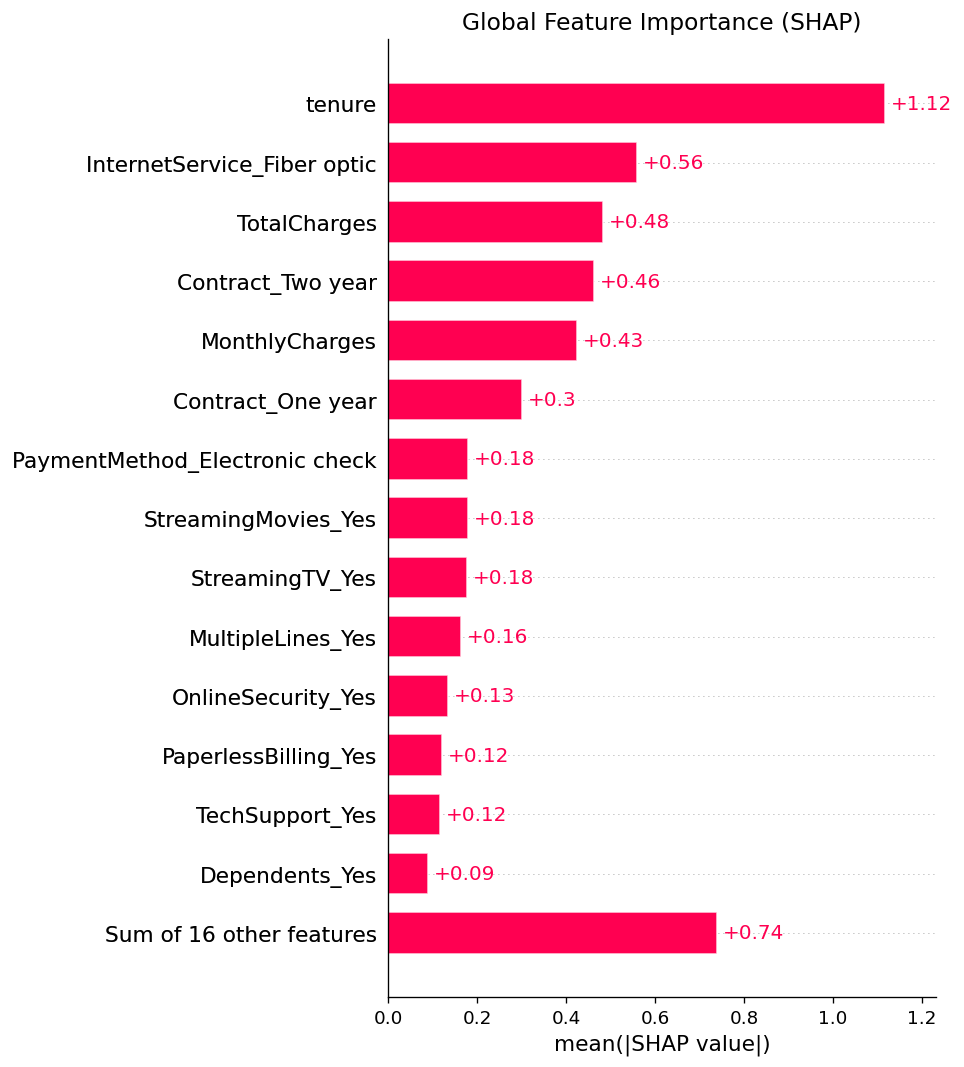

In [7]:
#Global Bar Plot

fig, ax = plt.subplots(figsize=(8, 6))

shap.plots.bar(
    shap_values,
    max_display=15,
    show=False
)

plt.title("Global Feature Importance (SHAP)", fontsize=14)
plt.tight_layout()
plt.savefig("../data/shap_bar.png", bbox_inches="tight")
plt.show()

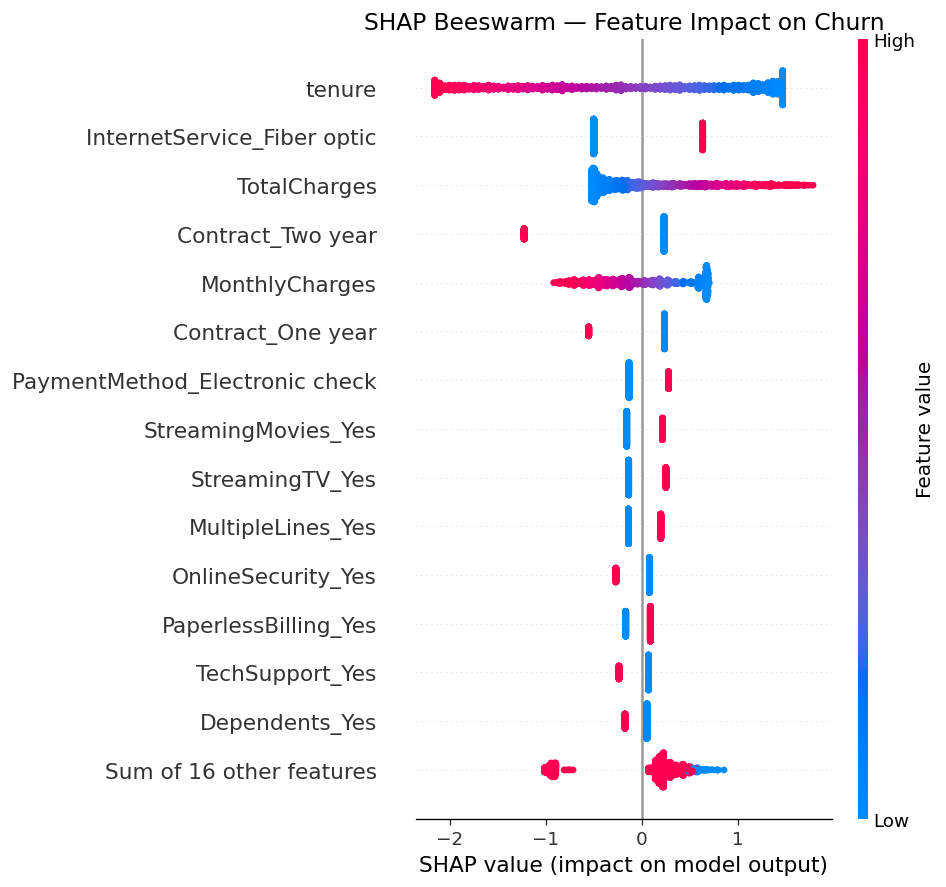

In [8]:
# Beeswarm Plot

fig, ax = plt.subplots(figsize=(8, 6))

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title("SHAP Beeswarm — Feature Impact on Churn", fontsize=14)
plt.tight_layout()
plt.savefig("../data/shap_beeswarm.png", bbox_inches="tight")
plt.show()

In [9]:
# Find a customer the model predicts will churn with high probability
y_prob_test = pipeline.predict_proba(X_test)[:, 1]

# Pick the customer with highest churn probability
churn_idx = y_prob_test.argmax()

print(f"Customer index: {churn_idx}")
print(f"Predicted churn probability: {y_prob_test[churn_idx]:.2%}")
print(f"Actual label: {'Churned' if y_test.iloc[churn_idx] == 1 else 'Did not churn'}")
print(f"\nCustomer details:")
print(X_test.iloc[churn_idx])

Customer index: 211
Predicted churn probability: 93.44%
Actual label: Did not churn

Customer details:
gender                          Male
SeniorCitizen                      1
Partner                           No
Dependents                        No
tenure                             3
PhoneService                     Yes
MultipleLines                    Yes
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                      Yes
StreamingMovies                  Yes
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                 94.85
TotalCharges                  335.75
Name: 3154, dtype: object


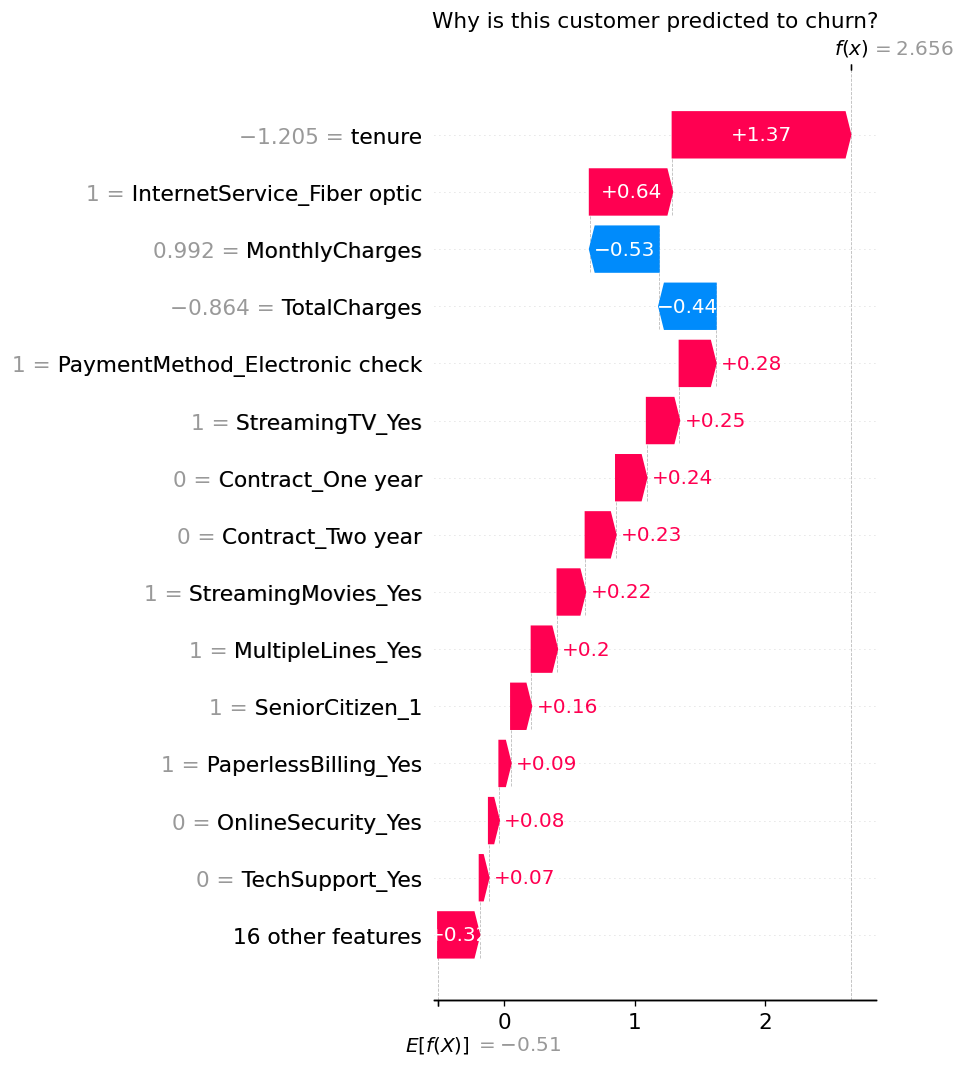

In [10]:
# Waterfall plot

shap.plots.waterfall(
    shap_values[churn_idx],
    max_display=15,
    show=False
)

plt.title(f"Why is this customer predicted to churn?", fontsize=13)
plt.tight_layout()
plt.savefig("../data/shap_waterfall.png", bbox_inches="tight")
plt.show()

Predicted churn probability: 0.47%
Actual label: Did not churn


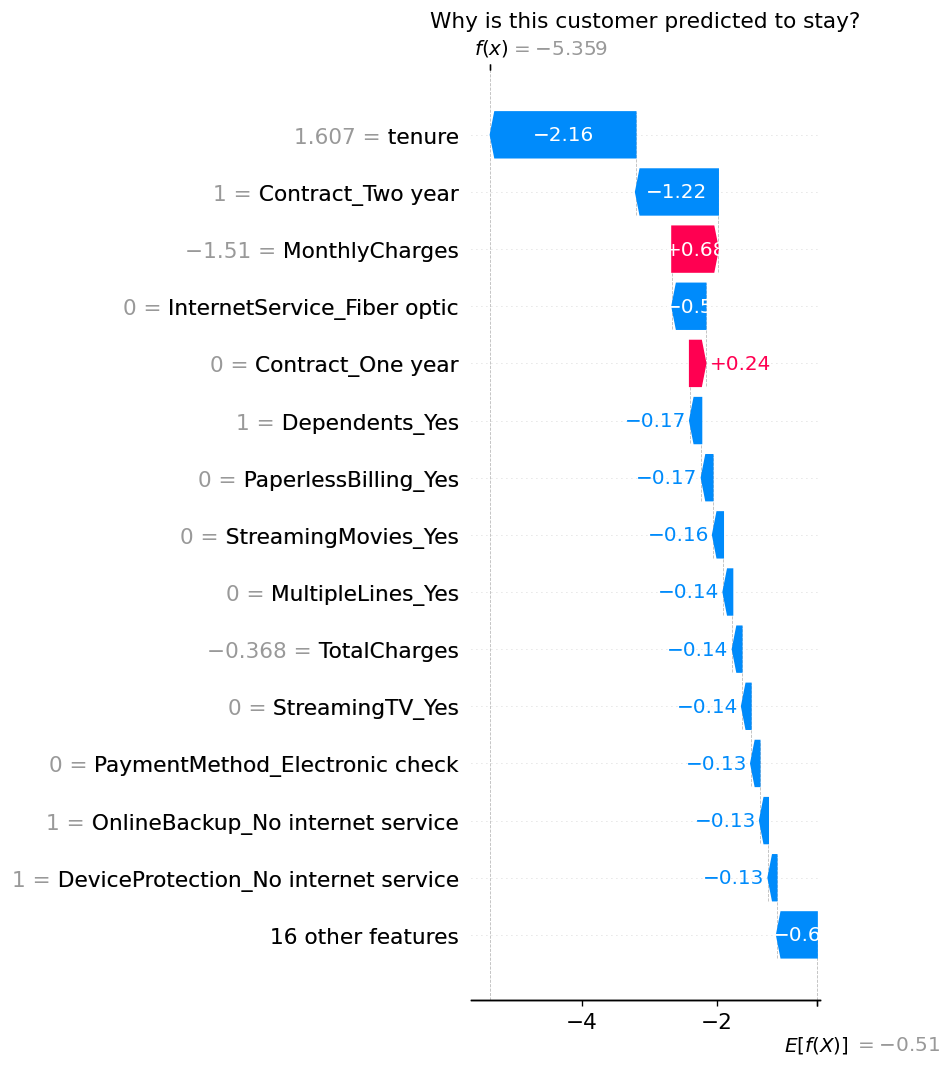

In [11]:
# Customer with lowest churn probability
no_churn_idx = y_prob_test.argmin()

print(f"Predicted churn probability: {y_prob_test[no_churn_idx]:.2%}")
print(f"Actual label: {'Churned' if y_test.iloc[no_churn_idx] == 1 else 'Did not churn'}")

shap.plots.waterfall(
    shap_values[no_churn_idx],
    max_display=15,
    show=False
)

plt.title("Why is this customer predicted to stay?", fontsize=13)
plt.tight_layout()
plt.savefig("../data/shap_waterfall_nochurn.png", bbox_inches="tight")
plt.show()